<div style="color:white; background-color: #2f4e16; padding: 20px; border-radius:8px; font-size:26px"><b style="font-weight: 700;"><center>HOTEL BOOKING CANCELLATION PREDICTION
</center></b></div>

The dataset comes from a Kaggle hotel booking classification problem.

<div style="background-color:  #dbf0c9; padding: 10px;">

## Business Objective

</div>

Hotel cancellations can affect revenue planning, staffing, room availability, and overbooking decisions.
The goal of this project is to build a machine learning classification model that predicts whether a booking is likely to be canceled using booking-related information.

This project focuses on:

- cleaning and preparing hotel booking data,
- reviewing possible data leakage,
- comparing baseline classification models,
- tuning a Random Forest model,
- evaluating model performance with business context,
- interpreting the most important cancellation drivers.


<div style="background-color:  #dbf0c9; padding: 10px;">

## Business Question

</div>

Can we predict whether a hotel booking will be canceled using booking characteristics such as lead time, deposit type, market segment, customer type, previous cancellations, and special requests?

From a business perspective, this prediction can help hotels anticipate cancellation risk and make better decisions about room inventory, staffing, and revenue management.




<div style="background-color:  #dbf0c9; padding: 10px;">

## Import Libraries

</div>

In [1]:
import pandas as pd
import numpy as np                          # for working with arrays and matrices

pd.set_option('display.max_rows', 500)      # Set max number of rows displayed
pd.set_option('display.max_columns', 500)   # Set max number of columns displayed
pd.set_option('display.width', 1000)

from pathlib import Path

# Visualizations
import matplotlib.pyplot as plt             # for creating plots
%matplotlib inline
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.preprocessing import OrdinalEncoder
from sklearn.compose import ColumnTransformer
import joblib

from collections import Counter
from imblearn.over_sampling import SMOTE

# Models Pkgs
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier


# Metrics Pkgs
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.metrics import roc_curve, roc_auc_score, confusion_matrix

from imblearn.pipeline import Pipeline as ImbPipeline

from sklearn.model_selection import GridSearchCV

# Avoid warnings
import warnings
warnings.filterwarnings('ignore')

In [2]:
from matplotlib import colors

# Customize the appearance of plots: (both the axes and the figure have a background color of #FFF9ED, which is a light beige color.)
sns.set(rc={"axes.facecolor":"#ffffef","figure.facecolor":"#ffffef"})

# cmap = colors.ListedColormap(["#682F2F", "#9E726F", "#D6B2B1", "#B9C0C9", "#9F8A78", "#F3AB60"])   # <-- `cmap` is short for colormap, which is used for mapping data values to colors in a plot.

<div style="background-color:  #dbf0c9; padding: 10px;">

## Load Data

</div>

- The project uses separate training and test datasets.
- The training dataset contains the target variable `is_canceled`, which indicates whether each booking was canceled.

At this stage, the goal is to load the data and inspect its basic structure before cleaning, preprocessing, and modeling.


In [3]:
DATA_DIR = Path("../data") if Path("../data").exists() else Path("data")
MODELS_DIR = Path("../models") if Path("../models").exists() else Path("models")
MODELS_DIR.mkdir(exist_ok=True)

df_train = pd.read_csv(DATA_DIR / "train_final.csv")
df_test = pd.read_csv(DATA_DIR / "test_final.csv")



<div style="background-color:  #dbf0c9; padding: 10px;">

## Initial Data Inspection

</div>

In this section, I inspect the structure of the datasets, check column types, review missing values, and look for duplicated records or unusual values that may affect the analysis.



In [4]:
display(df_train.head(10))

display(df_test.head(10))

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status_date
0,Resort Hotel,0,3,2016,February,7,12,0,2,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,E,F,0,No Deposit,0,Transient,81.00,1,0,2016-02-14
1,City Hotel,1,50,2016,November,47,18,1,2,2,0.0,0,BB,BEL,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,0,Transient,93.60,0,2,2016-10-09
2,City Hotel,0,14,2015,September,37,7,1,5,2,2.0,0,BB,ITA,Online TA,TA/TO,0,0,0,F,F,0,No Deposit,0,Contract,166.00,0,3,2015-09-13
3,City Hotel,0,18,2015,December,50,6,2,0,2,0.0,0,BB,ESP,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,0,Transient,107.00,0,0,2015-12-08
4,City Hotel,1,263,2016,September,40,29,2,4,2,0.0,0,BB,DEU,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,0,Transient,100.30,0,0,2016-01-18
5,Resort Hotel,0,45,2016,March,10,1,0,5,2,0.0,0,HB,DEU,Groups,Direct,0,0,0,E,G,1,No Deposit,0,Transient,106.00,0,1,2016-03-06
6,Resort Hotel,0,131,2015,December,52,22,2,5,2,0.0,0,HB,AUS,Offline TA/TO,TA/TO,0,0,0,D,D,1,No Deposit,0,Transient-Party,72.14,0,1,2015-12-29
7,Resort Hotel,0,152,2017,July,28,11,2,5,2,0.0,0,HB,CHE,Online TA,TA/TO,0,0,0,D,D,0,No Deposit,0,Transient-Party,194.86,0,2,2017-07-18
8,City Hotel,0,102,2015,October,42,16,0,2,2,0.0,0,HB,DEU,Offline TA/TO,TA/TO,0,0,0,A,E,0,No Deposit,0,Transient-Party,109.00,0,0,2015-10-18
9,Resort Hotel,0,4,2017,April,17,26,0,2,1,0.0,0,BB,PRT,Corporate,Corporate,1,0,1,A,A,0,No Deposit,0,Transient,45.00,0,0,2017-04-28


,hotel,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status_date
0,City Hotel,73,2016,July,28,6,0,2,1,0.0,0,SC,CN,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,0,Transient,107.10,0,0,2016-06-12
1,City Hotel,37,2015,October,43,24,2,5,1,1.0,0,SC,PRT,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,0,Transient,87.78,0,0,2015-10-31
2,City Hotel,190,2017,April,14,6,2,3,2,0.0,0,BB,PRT,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,0,Transient,88.40,0,0,2016-09-29
3,City Hotel,287,2016,August,35,24,1,4,2,0.0,0,BB,DEU,Direct,Direct,0,0,0,B,B,1,No Deposit,0,Transient,76.71,0,0,2016-08-29
4,Resort Hotel,386,2016,October,43,20,1,3,2,0.0,0,BB,PRT,Groups,Corporate,0,0,0,A,A,0,No Deposit,0,Transient-Party,49.00,0,0,2016-09-14
5,City Hotel,27,2015,September,40,30,0,2,2,0.0,0,BB,PRT,Offline TA/TO,TA/TO,0,0,0,A,A,0,Non Refund,21,Transient,108.00,0,0,2015-09-24
6,City Hotel,84,2017,April,15,11,0,4,3,0.0,0,BB,FRA,Online TA,TA/TO,0,0,0,D,D,0,No Deposit,0,Transient,166.50,0,0,2017-01-22
7,City Hotel,7,2017,January,5,29,1,0,2,0.0,0,SC,FRA,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,0,Transient,88.00,0,1,2017-01-30
8,City Hotel,56,2016,June,24,8,0,1,2,0.0,0,BB,PRT,Offline TA/TO,Corporate,0,0,0,A,A,0,No Deposit,0,Transient-Party,120.00,0,0,2016-06-02
9,City Hotel,106,2016,November,45,4,1,2,2,0.0,0,BB,CHE,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,0,Transient,90.00,0,2,2016-07-28


In [5]:
df_train.shape, df_test.shape

((44638, 29), (23525, 28))

In [6]:
 # Summary of data types and non-null counts in df_train
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44638 entries, 0 to 44637
Data columns (total 29 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   hotel                           44638 non-null  object 
 1   is_canceled                     44638 non-null  int64  
 2   lead_time                       44638 non-null  int64  
 3   arrival_date_year               44638 non-null  int64  
 4   arrival_date_month              44638 non-null  object 
 5   arrival_date_week_number        44638 non-null  int64  
 6   arrival_date_day_of_month       44638 non-null  int64  
 7   stays_in_weekend_nights         44638 non-null  int64  
 8   stays_in_week_nights            44638 non-null  int64  
 9   adults                          44638 non-null  int64  
 10  children                        44638 non-null  float64
 11  babies                          44638 non-null  int64  
 12  meal                            

In [7]:
# Summary of missing values per feature
miss_num = df_train.isna().sum()
miss_perc = round(miss_num / len(df_train) * 100, 1)

df_miss = pd.DataFrame({
    "No_missing": miss_num,
    "%_missing": miss_perc
}).sort_values(by="No_missing", ascending=False)

display(df_miss)


,No_missing,%_missing
hotel,0,0.0
distribution_channel,0,0.0
total_of_special_requests,0,0.0
required_car_parking_spaces,0,0.0
adr,0,0.0
customer_type,0,0.0
days_in_waiting_list,0,0.0
deposit_type,0,0.0
booking_changes,0,0.0
assigned_room_type,0,0.0


<div style="background-color:  #dbf0c9; padding: 10px;">

## Data Type Corrections

</div>

Some variables need to be converted to more appropriate data types before analysis and modeling.


In [8]:
# Convert children from float/object type to integer
df_train["children"] = df_train["children"].astype("int64")
df_test["children"] = df_test["children"].astype("int64")


In [9]:
# Convert reservation status date to datetime
df_train["reservation_status_date"] = pd.to_datetime(df_train["reservation_status_date"])
df_test["reservation_status_date"] = pd.to_datetime(df_test["reservation_status_date"])


`reservation_status_date` is converted to datetime for inspection, but it will not be used as a modeling feature because it can contain information from after the booking outcome.


<div style="background-color:  #dbf0c9; padding: 10px;">

### Target Variable

</div>

The target variable is `is_canceled`.

- `0` means the booking was not canceled.
- `1` means the booking was canceled.

Before modeling, I inspect the target distribution to understand whether the classification problem is balanced or imbalanced.



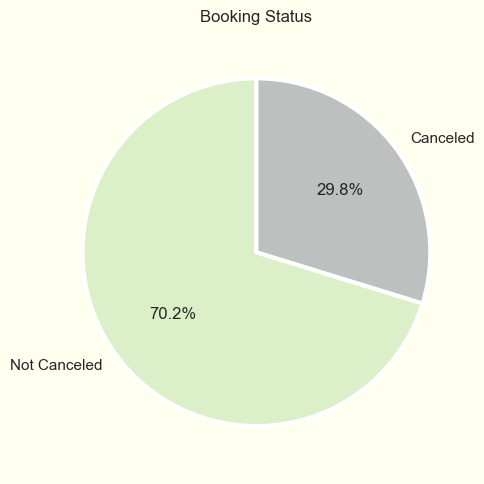

In [10]:
# Create data
booking_counts = df_train['is_canceled'].value_counts()
labels = ['Not Canceled', 'Canceled']  # Custom labels instead of 0 and 1
sizes = booking_counts.values

# --------------------------------------------------
# Pie Plot
fig, ax = plt.subplots(figsize = (5,5))

pcts = ax.pie(sizes,
              labels = labels,
              autopct = '%1.1f%%',
              colors = ['#dbf0c9', '#bcc0be'],
              wedgeprops={'linewidth': 3.0, 'edgecolor': 'white'},    # <------------- Style the wedges
              startangle = 90)

# Add a title
plt.title('Booking Status')

# Equal aspect ratio ensures that pie is drawn as a circle
plt.axis('equal')

plt.tight_layout()        # <------------- Adjust subplot spacing

# Display the chart
plt.show()

The target variable is moderately imbalanced: canceled bookings represent approximately 30% of the data.

This means that accuracy alone may not be enough to evaluate model performance. A model could achieve a reasonable accuracy by favoring the majority class (`Not Canceled`) while still missing many actual cancellations.

To address this issue, the modeling stage should consider:

- using stratified train-test splitting to preserve the class proportions in both sets,
- evaluating metrics beyond accuracy, such as precision, recall, F1-score, and ROC-AUC,
- applying resampling techniques such as oversampling, undersampling, or SMOTE when appropriate.



<div style="background-color:  #dbf0c9; padding: 10px;">

## Exploratory Data Analysis

</div>

In this section, I explore how cancellation behavior varies across booking characteristics such as hotel type, customer type, market segment, deposit type, lead time, and special requests.

The goal is to identify patterns that may help explain cancellation risk before building the predictive models.


#### Hotel type by Cancellation Rate

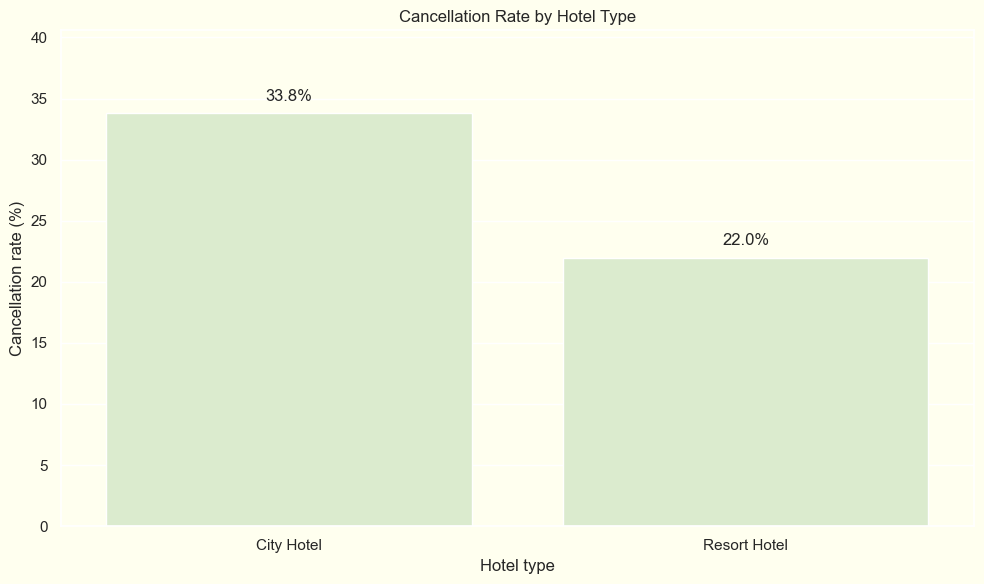

In [11]:
hotel_cancel_rate = ( df_train
                      .groupby("hotel")["is_canceled"]
                      .mean()
                      .reset_index()
)

hotel_cancel_rate["cancellation_rate"] = hotel_cancel_rate["is_canceled"] * 100

plt.figure(figsize=(10, 6))
sns.barplot( data = hotel_cancel_rate,
             x = "hotel",
             y = "cancellation_rate",
             color = "#dbf0c9"
           )

plt.title("Cancellation Rate by Hotel Type")
plt.xlabel("Hotel type")
plt.ylabel("Cancellation rate (%)")
plt.ylim(0, hotel_cancel_rate["cancellation_rate"].max() * 1.2)

for index, row in hotel_cancel_rate.iterrows():
    plt.text( index,
              row["cancellation_rate"] + 1,
              f"{row['cancellation_rate']:.1f}%",
              ha="center"
            )

plt.tight_layout()
plt.show()


City Hotel bookings show a higher cancellation rate than Resort Hotel bookings: approximately 33.8% compared with 22.0%. This difference of about 11.8 percentage points suggests that hotel type is related to cancellation behavior, possibly due to differences in customer profile, booking purpose, travel flexibility, or urban travel patterns.


#### Cancellation Rates based on the Deposit Type

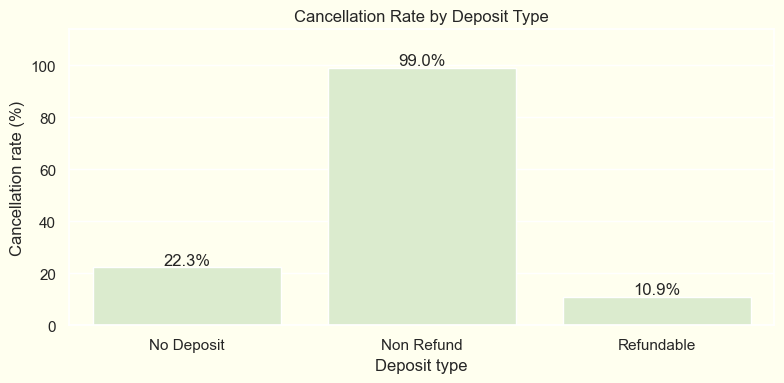

In [12]:
deposit_cancel_rate = ( df_train
                        .groupby("deposit_type")["is_canceled"]
                        .mean()
                        .reset_index()
                      )

deposit_cancel_rate["cancellation_rate"] = deposit_cancel_rate["is_canceled"] * 100

plt.figure(figsize=(8, 4))
sns.barplot( data = deposit_cancel_rate,
             x = "deposit_type",
             y = "cancellation_rate",
             color = "#dbf0c9"
           )

plt.title("Cancellation Rate by Deposit Type")
plt.xlabel("Deposit type")
plt.ylabel("Cancellation rate (%)")
plt.ylim(0, deposit_cancel_rate["cancellation_rate"].max() * 1.15)

for index, row in deposit_cancel_rate.iterrows():
    plt.text(index,
             row["cancellation_rate"] + 1,
             f"{row['cancellation_rate']:.1f}%",
             ha = "center"
            )

plt.tight_layout()
plt.show()


**Deposit type shows one of the strongest relationships with cancellation behavior**. Bookings with a `Non Refund` deposit have an extremely high cancellation rate of approximately 99.0%, compared with 22.3% for bookings with no deposit and 10.9% for refundable bookings.

This pattern may seem counterintuitive **because non-refundable deposits usually suggest stronger commitment. However, in this dataset, `Non Refund` is highly associated with cancellations.** This may reflect specific booking policies, agency/group booking behavior, or how deposit rules were applied in the original data.

**Because this feature is available at booking time and shows a strong relationship with the target, it is an important predictor for the model.**


#### Cancellation Rates based on Special Requests

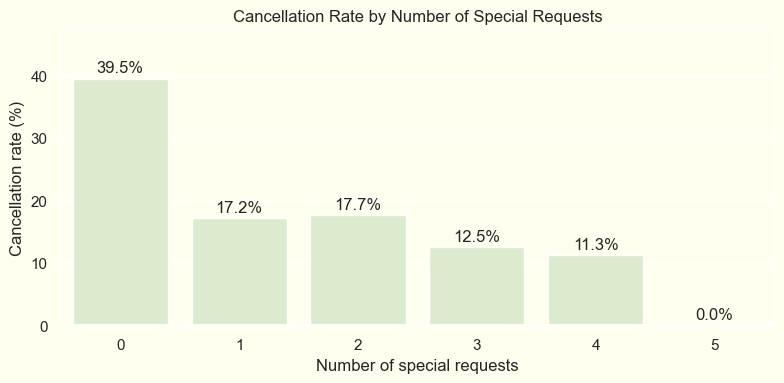

In [13]:
special_requests_cancel_rate = ( df_train
                                .groupby("total_of_special_requests")["is_canceled"]
                                .mean()
                                .reset_index()
                               )

special_requests_cancel_rate["cancellation_rate"] = ( special_requests_cancel_rate["is_canceled"] * 100
)

plt.figure(figsize=(8, 4))

sns.barplot( data=special_requests_cancel_rate,
             x="total_of_special_requests",
             y="cancellation_rate",
             color="#dbf0c9"
           )

plt.title("Cancellation Rate by Number of Special Requests")
plt.xlabel("Number of special requests")
plt.ylabel("Cancellation rate (%)")
plt.ylim(0, special_requests_cancel_rate["cancellation_rate"].max() * 1.2)

for index, row in special_requests_cancel_rate.iterrows():
    plt.text( index,
              row["cancellation_rate"] + 1,
              f"{row['cancellation_rate']:.1f}%",
              ha="center"
            )

plt.tight_layout()
plt.show()


**Bookings with no special requests show the highest cancellation rate, approximately 39.5%. Once guests make at least one special request, the cancellation rate drops substantially.**

This suggests that special requests may act as a customer commitment signal. Guests who provide specific stay preferences may be more engaged with the booking and therefore less likely to cancel.

_The category with five special requests shows 0.0% cancellation, but this group may contain very few observations. For that reason, it should be interpreted carefully:_


In [14]:
special_requests_summary = (df_train
                            .groupby("total_of_special_requests")
                            .agg(bookings=("is_canceled", "size"),
                                 cancellation_rate=("is_canceled", "mean")
                            )
                            .reset_index()
                           )

special_requests_summary["cancellation_rate"] = (special_requests_summary["cancellation_rate"] * 100).round(1)

special_requests_summary


,total_of_special_requests,bookings,cancellation_rate
0,0,25294,39.5
1,1,13071,17.2
2,2,5125,17.7
3,3,1000,12.5
4,4,133,11.3
5,5,15,0.0


The table confirms that most bookings have zero or one special request. The group with five special requests contains only 15 bookings, so its 0.0% cancellation rate should be interpreted with caution.

The broader and more reliable pattern is that bookings with at least one special request tend to have a substantially lower cancellation rate than bookings with no special requests.


#### Lead Time Distribution by Cancellation Status

To improve readability, the plot below excludes the most extreme 1% of `lead_time` values. This keeps the main distribution visible while preserving the comparison between canceled and not-canceled bookings.


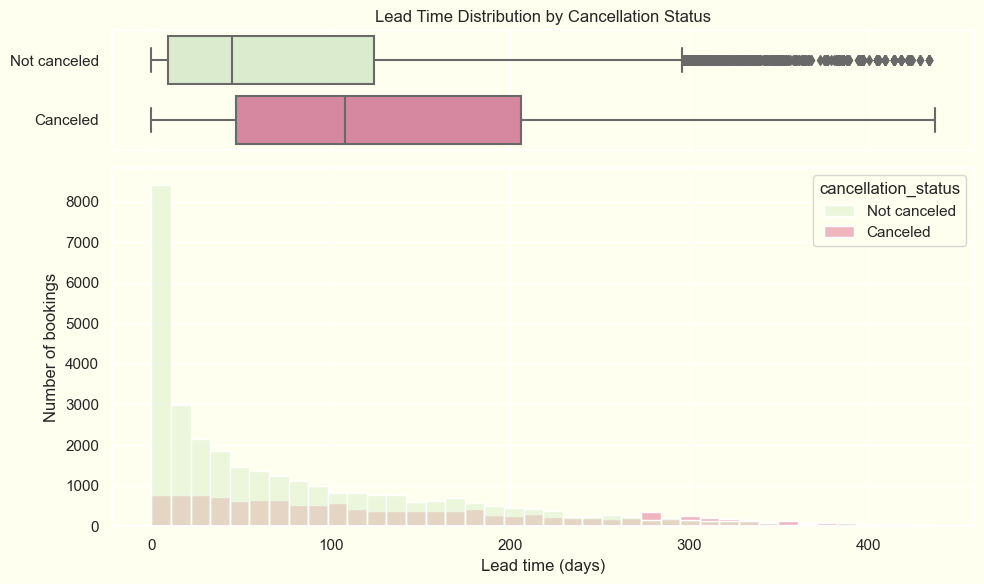

In [15]:
# For more readability, creating a second version limited to the 99th percentile:
lead_time_limit = df_train["lead_time"].quantile(0.99)

df_plot = df_train.copy()
df_plot["cancellation_status"] = df_plot["is_canceled"].map({
    0: "Not canceled",
    1: "Canceled"
})

palette = { "Not canceled": "#dbf0c9",
            "Canceled": "#e27b9b"
}

df_plot_limited = df_plot[df_plot["lead_time"] <= lead_time_limit]

df_plot_limited["cancellation_status"] = df_plot_limited["is_canceled"].map({
    0: "Not canceled",
    1: "Canceled"
})

palette = { "Not canceled": "#dbf0c9",
            "Canceled": "#e27b9b"
}

fig, axs = plt.subplots(
    nrows=2,
    ncols=1,
    sharex=True,
    figsize=(10, 6),
    gridspec_kw={"height_ratios": (0.3, 0.9)}
)

sns.boxplot(
    data=df_plot_limited,
    x="lead_time",
    y="cancellation_status",
    ax=axs[0],
    palette=palette,
    orient="h"
)

sns.histplot(
    data=df_plot_limited,
    x="lead_time",
    hue="cancellation_status",
    multiple="layer",
    palette=palette,
    alpha=0.55,
    bins=40,
    ax=axs[1]
)

axs[0].set_title("Lead Time Distribution by Cancellation Status")
axs[0].set_xlabel("")
axs[0].set_ylabel("")

axs[1].set_xlabel("Lead time (days)")
axs[1].set_ylabel("Number of bookings")

plt.tight_layout()
plt.show()


Canceled bookings tend to have longer lead times than not-canceled bookings. The boxplot shows that the distribution for canceled bookings is shifted to the right, meaning that cancellations are more common among bookings made further in advance.

This pattern is reasonable from a business perspective: the more time between booking and arrival, the more opportunity customers have for plans to change.

Even after limiting the plot to the 99th percentile, the difference between the two groups remains visible, supporting the importance of `lead_time` as a predictor.


#### ADR Distribution by Cancellation Status

`adr` means **Average Daily Rate**. In the context of hotel bookings, it represents the average price paid per room night.

In this project, `adr` is useful because price level may be associated with cancellation behavior. It can also reflect seasonality, hotel type, room type, demand level, or customer segment.


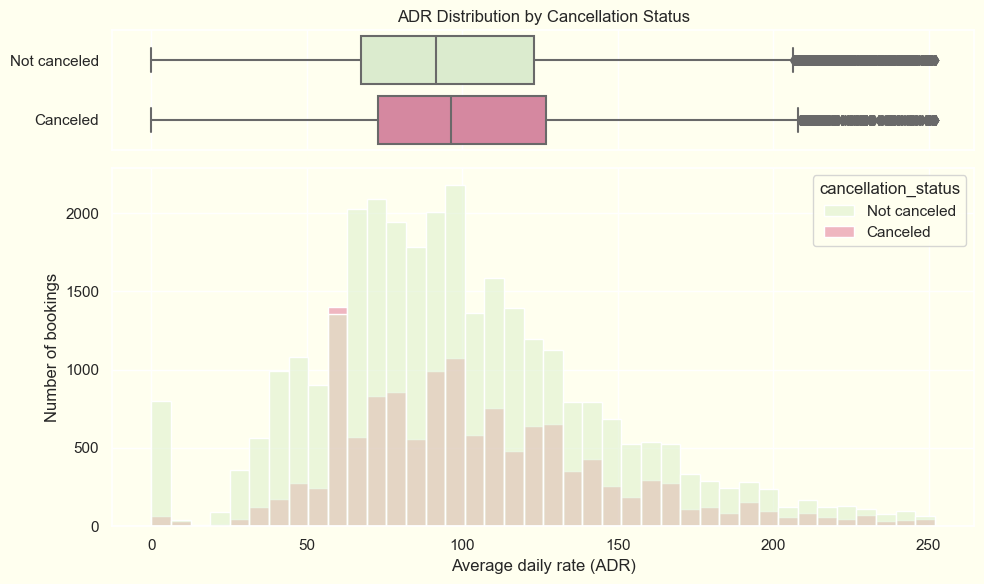

In [16]:
df_plot_adr = df_train.copy()

df_plot_adr["cancellation_status"] = df_plot_adr["is_canceled"].map({
    0: "Not canceled",
    1: "Canceled"
})

adr_limit = df_plot_adr["adr"].quantile(0.99)
df_plot_adr_limited = df_plot_adr[df_plot_adr["adr"] <= adr_limit]

palette = {
    "Not canceled": "#dbf0c9",
    "Canceled": "#e27b9b"
}

fig, axs = plt.subplots(
    nrows=2,
    ncols=1,
    sharex=True,
    figsize=(10, 6),
    gridspec_kw={"height_ratios": (0.3, 0.9)}
)

sns.boxplot(
    data=df_plot_adr_limited,
    x="adr",
    y="cancellation_status",
    ax=axs[0],
    palette=palette,
    orient="h"
)

sns.histplot(
    data=df_plot_adr_limited,
    x="adr",
    hue="cancellation_status",
    multiple="layer",
    palette=palette,
    alpha=0.55,
    bins=40,
    ax=axs[1]
)

axs[0].set_title("ADR Distribution by Cancellation Status")
axs[0].set_xlabel("")
axs[0].set_ylabel("")

axs[1].set_xlabel("Average daily rate (ADR)")
axs[1].set_ylabel("Number of bookings")

plt.tight_layout()
plt.show()


To improve readability, the plot excludes the most extreme 1% of `adr` values. This helps compare the main distribution without allowing extreme price values to stretch the x-axis.

The ADR distributions for canceled and not-canceled bookings overlap substantially, but canceled bookings appear slightly shifted toward higher ADR values.

This suggests that price level may contain some predictive signal, although it is unlikely to explain cancellation behavior by itself. The relationship should be interpreted as an association, not as evidence that higher ADR directly causes cancellations.

The importance of `adr` in the Random Forest model may also reflect its interaction with other variables, such as seasonality, hotel type, room type, market segment, or lead time.



####  Previous Cancellations vs Cancellation Rate

In [17]:
# I use a grouped cancellation-rate table first, because this variable may have small groups at higher values:

previous_cancellations_summary = ( df_train
                                   .groupby("previous_cancellations")
                                   .agg( bookings=("is_canceled", "size"),
                                         cancellation_rate=("is_canceled", "mean")
                                 ).reset_index()
                            )

previous_cancellations_summary["cancellation_rate"] = (previous_cancellations_summary["cancellation_rate"] * 100
).round(1)

previous_cancellations_summary


,previous_cancellations,bookings,cancellation_rate
0,0,42654,27.0
1,1,1842,92.0
2,2,42,26.2
3,3,26,11.5
4,4,8,37.5
5,5,5,0.0
6,6,7,28.6
7,11,16,25.0
8,13,5,80.0
9,14,4,100.0


Many higher values have very few bookings, so plotting every value would be noisy.
Therefore I will group the values into:
- `0`
- `1`
- `2+`

In [18]:
df_plot = df_train.copy()

df_plot["previous_cancellations_group"] = df_plot["previous_cancellations"].apply(
    lambda x: "0" if x == 0 else "1" if x == 1 else "2+"
)

previous_cancellations_grouped = ( df_plot
                                    .groupby("previous_cancellations_group")
                                    .agg( bookings=("is_canceled", "size"),
                                          cancellation_rate=("is_canceled", "mean")
                                    )
                                    .reset_index()
)

previous_cancellations_grouped["cancellation_rate"] = (previous_cancellations_grouped["cancellation_rate"] * 100
).round(1)

previous_cancellations_grouped

,previous_cancellations_group,bookings,cancellation_rate
0,0,42654,27.0
1,1,1842,92.0
2,2+,142,42.3


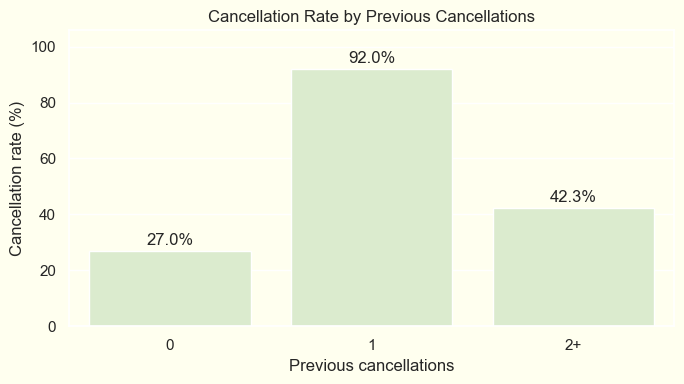

In [19]:
order = ["0", "1", "2+"]

plt.figure(figsize=(7, 4))

sns.barplot( data = previous_cancellations_grouped,
             x = "previous_cancellations_group",
             y = "cancellation_rate",
             order = order,
             color = "#dbf0c9"
           )

plt.title("Cancellation Rate by Previous Cancellations")
plt.xlabel("Previous cancellations")
plt.ylabel("Cancellation rate (%)")
plt.ylim(0, previous_cancellations_grouped["cancellation_rate"].max() * 1.15)

for index, row in previous_cancellations_grouped.set_index("previous_cancellations_group").loc[order].reset_index().iterrows():
    plt.text(index,
             row["cancellation_rate"] + 2,
             f"{row['cancellation_rate']:.1f}%",
             ha="center"
            )

plt.tight_layout()
plt.show()

Bookings with one previous cancellation show a much higher cancellation rate than bookings with no previous cancellations. This suggests that past cancellation behavior is an important predictor of future cancellation risk.

The `2+` group contains more varied behavior and may include relatively small subgroups, so it should be interpreted with caution. The strongest and most reliable pattern is the contrast between guests with no previous cancellations and guests with one previous cancellation.


### Market Segment vs Cancellation Rate

In [20]:
market_segment_cancel_rate = (df_train
                              .groupby("market_segment")
                              .agg(bookings=("is_canceled", "size"),
                                   cancellation_rate=("is_canceled", "mean")
                             )
                             .reset_index()
)

market_segment_cancel_rate["cancellation_rate"] = (market_segment_cancel_rate["cancellation_rate"] * 100
).round(1)

market_segment_cancel_rate = market_segment_cancel_rate.sort_values(by="cancellation_rate", ascending=False)

market_segment_cancel_rate

,market_segment,bookings,cancellation_rate
4,Groups,6868,52.3
6,Online TA,21325,29.6
5,Offline TA/TO,9085,27.1
0,Aviation,84,17.9
2,Corporate,2046,14.1
3,Direct,4922,12.1
1,Complementary,308,6.8


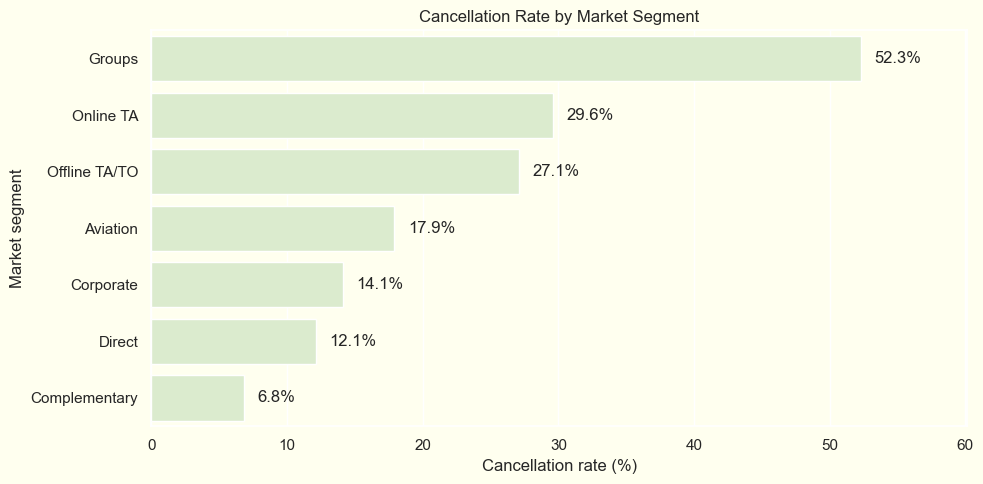

In [21]:
market_segment_cancel_rate = market_segment_cancel_rate.reset_index(drop=True)

plt.figure(figsize=(10, 5))

ax = sns.barplot(data = market_segment_cancel_rate,
                 x = "cancellation_rate",
                 y = "market_segment",
                 color = "#dbf0c9"
)

plt.title("Cancellation Rate by Market Segment")
plt.xlabel("Cancellation rate (%)")
plt.ylabel("Market segment")
plt.xlim(0, market_segment_cancel_rate["cancellation_rate"].max() * 1.15)

for i, row in market_segment_cancel_rate.iterrows():
    ax.text( row["cancellation_rate"] + 1,
             i,
             f"{row['cancellation_rate']:.1f}%",
             va="center"
           )

plt.tight_layout()
plt.show()


Cancellation rates vary substantially across market segments. The `Groups` segment shows the highest cancellation rate, followed by `Online TA` and `Offline TA/TO`.

This suggests that the booking source and customer segment are important context for cancellation risk. Group bookings may depend on coordinated travel plans, while online travel agency bookings may be easier for customers to compare, modify, or cancel.

Because `market_segment_Online TA` and `market_segment_Groups` also appear among the top model predictors, this EDA pattern is consistent with the final feature-importance results.


### Customer Type vs Cancellation Rate

In [22]:
customer_type_cancel_rate = ( df_train
                              .groupby("customer_type")
                              .agg( bookings=("is_canceled", "size"),
                                    cancellation_rate=("is_canceled", "mean")
                                  )
                                  .reset_index()
)

customer_type_cancel_rate["cancellation_rate"] = (customer_type_cancel_rate["cancellation_rate"] * 100
).round(1)

customer_type_cancel_rate = customer_type_cancel_rate.sort_values( by="cancellation_rate",  ascending=False).reset_index(drop=True)

customer_type_cancel_rate


,customer_type,bookings,cancellation_rate
0,Transient,32982,33.4
1,Contract,1594,23.3
2,Transient-Party,9826,19.2
3,Group,236,8.1


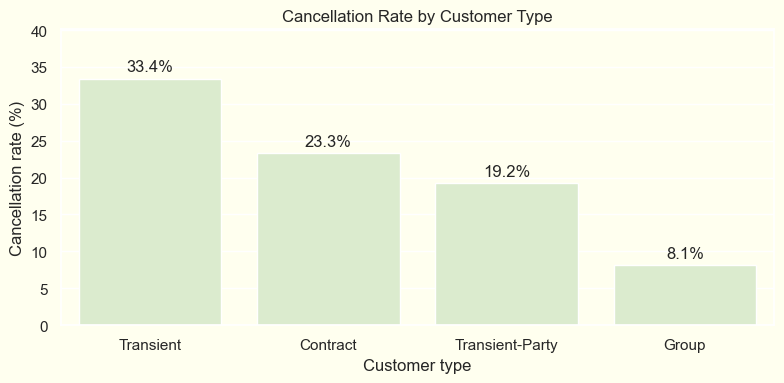

In [23]:
plt.figure(figsize=(8, 4))

ax = sns.barplot(data = customer_type_cancel_rate,
                 x = "customer_type",
                 y = "cancellation_rate",
                 color = "#dbf0c9"
                )

plt.title("Cancellation Rate by Customer Type")
plt.xlabel("Customer type")
plt.ylabel("Cancellation rate (%)")
plt.ylim(0, customer_type_cancel_rate["cancellation_rate"].max() * 1.2)

for i, row in customer_type_cancel_rate.iterrows():
    ax.text(i,
            row["cancellation_rate"] + 1,
            f"{row['cancellation_rate']:.1f}%",
            ha="center"
           )

plt.tight_layout()
plt.show()

Cancellation rates differ by customer type. `Transient` customers show the highest cancellation rate, approximately 33.4%, while `Group` customers show the lowest rate, approximately 8.1%.

This suggests that individual or short-term bookings may be more flexible and more likely to be canceled than group bookings. Group bookings may involve more planning, coordination, or organizational commitment, which can reduce cancellation risk.

This pattern is consistent with the feature-importance results, where `customer_type_Transient` appears among the strongest predictors.

Note: Since `Group` has a low cancellation rate, I will check the number of bookings in each customer type too:


In [24]:
customer_type_summary = (df_train
                        .groupby("customer_type")
                        .agg(
                            bookings=("is_canceled", "size"),
                            cancellation_rate=("is_canceled", "mean")
                            )
                        .reset_index()
)

customer_type_summary["cancellation_rate"] = (customer_type_summary["cancellation_rate"] * 100
).round(1)

customer_type_summary = customer_type_summary.sort_values(by="cancellation_rate",
                                                          ascending=False
                                                         ).reset_index(drop=True)

customer_type_summary

,customer_type,bookings,cancellation_rate
0,Transient,32982,33.4
1,Contract,1594,23.3
2,Transient-Party,9826,19.2
3,Group,236,8.1


The table shows that `Transient` customers have the highest cancellation rate, approximately 33.4%, and also represent the largest customer group in the dataset. This makes the pattern especially relevant for the model and for business interpretation.

`Group` customers show the lowest cancellation rate, approximately 8.1%, but this category contains only 236 bookings. Therefore, this result should be interpreted with some caution.

Overall, customer type appears to be related to cancellation behavior. Individual or short-term bookings may be more flexible and more likely to be canceled, while group bookings may involve more coordination or commitment.


### Distribution Channel vs Cancellation Rate

In [25]:
distribution_channel_summary = (df_train
                                .groupby("distribution_channel")
                                .agg(
                                    bookings=("is_canceled", "size"),
                                    cancellation_rate=("is_canceled", "mean")
                                )
                                .reset_index()
                               )

distribution_channel_summary["cancellation_rate"] = (
    distribution_channel_summary["cancellation_rate"] * 100
).round(1)

distribution_channel_summary = distribution_channel_summary.sort_values(by="cancellation_rate",     ascending=False).reset_index(drop=True)

distribution_channel_summary

,distribution_channel,bookings,cancellation_rate
0,TA/TO,36298,33.3
1,GDS,83,22.9
2,Corporate,2535,16.4
3,Direct,5722,13.6


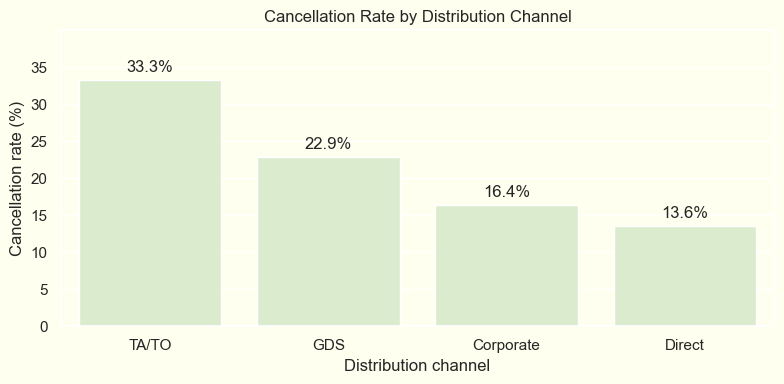

In [26]:
plt.figure(figsize=(8, 4))

ax = sns.barplot(data = distribution_channel_summary,
                 x = "distribution_channel",
                 y = "cancellation_rate",
                 color = "#dbf0c9"
                )

plt.title("Cancellation Rate by Distribution Channel")
plt.xlabel("Distribution channel")
plt.ylabel("Cancellation rate (%)")
plt.ylim(0, distribution_channel_summary["cancellation_rate"].max() * 1.2)

for i, row in distribution_channel_summary.iterrows():
    ax.text(i,
            row["cancellation_rate"] + 1,
            f"{row['cancellation_rate']:.1f}%",
            ha="center"
           )

plt.tight_layout()
plt.show()

The `TA/TO` distribution channel has the highest cancellation rate, approximately 33.3%, and also represents the largest group of bookings in the dataset. This makes it an important and reliable cancellation-risk signal.

Direct bookings show a much lower cancellation rate, approximately 13.6%, which may suggest stronger customer commitment or a different booking context.

The `GDS` channel has a cancellation rate of 22.9%, but it contains only 83 bookings, so this result should be interpreted cautiously. Overall, the distribution channel appears to capture meaningful differences in booking behavior.


<div style="background-color:  #eff8e7; padding: 10px;">

## EDA Summary

The exploratory analysis suggests that cancellation behavior is related to several booking characteristics:

- `deposit_type` shows the strongest difference in cancellation rates, especially for non-refundable bookings.
- `total_of_special_requests` shows that bookings with no special requests have a substantially higher cancellation rate than bookings with at least one special request.
- `lead_time` is associated with cancellation risk, with canceled bookings tending to have longer lead times.
- `adr` shows overlapping distributions between canceled and not-canceled bookings, but canceled bookings appear slightly shifted toward higher average daily rates.
- `previous_cancellations` shows that past cancellation behavior is related to future cancellation risk.
- `market_segment`, `customer_type`, and `distribution_channel` show meaningful differences in cancellation rates across booking segments.

These patterns support the use of these variables in the modeling stage and are consistent with the final feature-importance results.

</div>


<div style="background-color:  #dbf0c9; padding: 10px;">

## Feature Preparation and Preprocessing

</div>

Before training the models, I prepare the feature matrix and target variable, remove columns that should not be used for prediction, and define the preprocessing steps for categorical and numerical variables.

The preprocessing includes:

- removing unavailable or leakage-prone variables,
- encoding categorical variables,
- scaling numerical variables,
- preparing the data for classification models.




### Feature Availability and Data Leakage Review

Before modeling, I reviewed whether each variable would realistically be available at prediction time.

A key principle in this project is: **do not use future information to predict the future**.
In other words, the model should only use information that would realistically be available before the cancellation outcome is known.

- `reservation_status_date` is removed because it can contain information from after the booking outcome, especially for canceled bookings. Using it would risk leaking future information into the model.
- `reserved_room_type` is known at booking time, while `assigned_room_type` may be assigned later by the hotel. For a realistic booking-time cancellation prediction problem, `assigned_room_type` should be removed to avoid possible data leakage.
- `market_segment` and `distribution_channel` may be correlated because both describe how the booking reached the hotel. However, both are available from the booking channel context, so they can be kept and evaluated during modeling.
- `is_canceled` is the target variable. It is available in the training data, but not in the test data that would be used for prediction.
- `country` is not removed because of data leakage. It is usually available at booking time. However, it is removed to keep the model simpler and more generalizable, since it contains many categories and may create sparse encoded features.



In [27]:
# Remove leakage-prone and high-cardinality columns
cols_to_drop = ["assigned_room_type", "reservation_status_date", "country"]

df_train.drop(cols_to_drop, axis=1, inplace=True)
df_test.drop(cols_to_drop, axis=1, inplace=True)

In [28]:
# Checking..

df_train.columns.tolist()

['hotel',
 'is_canceled',
 'lead_time',
 'arrival_date_year',
 'arrival_date_month',
 'arrival_date_week_number',
 'arrival_date_day_of_month',
 'stays_in_weekend_nights',
 'stays_in_week_nights',
 'adults',
 'children',
 'babies',
 'meal',
 'market_segment',
 'distribution_channel',
 'is_repeated_guest',
 'previous_cancellations',
 'previous_bookings_not_canceled',
 'reserved_room_type',
 'booking_changes',
 'deposit_type',
 'days_in_waiting_list',
 'customer_type',
 'adr',
 'required_car_parking_spaces',
 'total_of_special_requests']

In [29]:
X = df_train.drop("is_canceled", axis=1)
y = df_train["is_canceled"]

# Stratify keeps approximately the same cancellation proportion in both sets, since the data contains  class imbalance.
X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size=0.3,
                                                    random_state=42,
                                                    stratify=y
                                                )

In [30]:
print("Training target distribution:")
display(y_train.value_counts(normalize=True).mul(100).round(1))

print("Test target distribution:")
display(y_test.value_counts(normalize=True).mul(100).round(1))

Training target distribution:


is_canceled
0    70.2
1    29.8
Name: proportion, dtype: float64

Test target distribution:


is_canceled
0    70.2
1    29.8
Name: proportion, dtype: float64

The target distribution is preserved in both training and test sets, which is important because the target variable is moderately imbalanced.


### Define Feature Groups

Before applying preprocessing, I separate the features into categorical and numerical groups.

- Categorical variables will be encoded.
- Numerical variables will be scaled when needed.
- `arrival_date_month` is ordinal in calendar order, so it will be ordinal encoded separately.



In [31]:
cols_ohe = [col for col in X_train.columns if X_train[col].dtype == "object" and col != "arrival_date_month"]

cols_sts = [col for col in X_train.columns if X_train[col].dtype != "object"]

col_le = ["arrival_date_month"]

display(cols_ohe)
display(cols_sts)
display(col_le)


['hotel',
 'meal',
 'market_segment',
 'distribution_channel',
 'reserved_room_type',
 'deposit_type',
 'customer_type']

['lead_time',
 'arrival_date_year',
 'arrival_date_week_number',
 'arrival_date_day_of_month',
 'stays_in_weekend_nights',
 'stays_in_week_nights',
 'adults',
 'children',
 'babies',
 'is_repeated_guest',
 'previous_cancellations',
 'previous_bookings_not_canceled',
 'booking_changes',
 'days_in_waiting_list',
 'adr',
 'required_car_parking_spaces',
 'total_of_special_requests']

['arrival_date_month']

### Build Preprocessing Pipeline

The preprocessing pipeline applies different transformations depending on the feature type:

- One-hot encoding for nominal categorical variables,
- ordinal encoding for `arrival_date_month`,
- standard scaling for numerical variables.

_The same preprocessing steps are fitted on the training data and then applied to the test data._


In [32]:
def data_transf_woF(X_train, X_test, cols_sts, cols_ohe, col_le):
    scaler =  StandardScaler()

    ohe_encoder = OneHotEncoder(handle_unknown = 'ignore',
                                sparse = False,
                                drop = 'first'
                               )

    # Define month order explicitly so ordinal encoding follows calendar order.
    month_order = [["January", "February", "March", "April", "May", "June", "July", "August", "September", "October", "November", "December" ]]

    ord_encoder = OrdinalEncoder(categories=month_order)


    transformer = ColumnTransformer(transformers=[("num_std", scaler, cols_sts),
                                                  ("ohe_enc", ohe_encoder, cols_ohe),
                                                  ("ord_enc", ord_encoder, col_le)
                                                 ], remainder="passthrough"
                                   )

    X_train_transformed = transformer.fit_transform(X_train)
    X_test_transformed = transformer.transform(X_test)

    joblib.dump(transformer, MODELS_DIR / "preprocessing_transformer.pkl")

    num_features = cols_sts
    cat_features = transformer.named_transformers_["ohe_enc"].get_feature_names_out(cols_ohe)
    all_features = list(num_features) + list(cat_features) + list(col_le)

    X_traintr = pd.DataFrame(X_train_transformed,
                             columns=all_features,
                             index=X_train.index
                            )

    X_testtr = pd.DataFrame(X_test_transformed,
                            columns=all_features,
                            index=X_test.index
                           )

    return X_traintr, X_testtr

In [33]:
X_traintr, X_testtr = data_transf_woF(X_train,
                                  X_test,
                                  cols_sts,
                                  cols_ohe,
                                  col_le
                                  )

display(X_traintr.head())
display(X_testtr.head())
display(X_traintr.shape,
        X_testtr.shape
       )

,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests,hotel_Resort Hotel,meal_FB,meal_HB,meal_SC,meal_Undefined,market_segment_Complementary,market_segment_Corporate,market_segment_Direct,market_segment_Groups,market_segment_Offline TA/TO,market_segment_Online TA,distribution_channel_Direct,distribution_channel_GDS,distribution_channel_TA/TO,reserved_room_type_B,reserved_room_type_C,reserved_room_type_D,reserved_room_type_E,reserved_room_type_F,reserved_room_type_G,reserved_room_type_H,reserved_room_type_P,deposit_type_Non Refund,deposit_type_Refundable,customer_type_Group,customer_type_Transient,customer_type_Transient-Party,arrival_date_month
38090,-0.305634,-0.216992,1.160741,0.136621,0.066047,-1.302990,-1.410736,-0.261434,-0.09,-0.18876,-0.097568,-0.094336,-0.356636,-0.123234,0.277305,-0.263541,-0.749425,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,9.0
17031,0.144771,1.199371,-0.522779,0.136621,-0.930424,0.774189,0.246526,-0.261434,-0.09,-0.18876,-0.097568,-0.094336,4.153662,-0.123234,0.457403,-0.263541,0.499990,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,4.0
41495,0.001025,-0.216992,-1.401137,0.363331,-0.930424,-0.783695,0.246526,-0.261434,-0.09,-0.18876,1.429032,-0.094336,-0.356636,-0.123234,-0.443089,-0.263541,-0.749425,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
6352,0.154354,-0.216992,-1.327940,1.270173,-0.930424,-0.783695,0.246526,-0.261434,-0.09,-0.18876,-0.097568,-0.094336,2.650230,-0.123234,-2.069122,-0.263541,-0.749425,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
41045,-0.516462,1.199371,-0.229993,-0.090090,-0.930424,-0.264400,0.246526,-0.261434,-0.09,-0.18876,-0.097568,-0.094336,-0.356636,-0.123234,0.997699,-0.263541,0.499990,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,5.0


,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests,hotel_Resort Hotel,meal_FB,meal_HB,meal_SC,meal_Undefined,market_segment_Complementary,market_segment_Corporate,market_segment_Direct,market_segment_Groups,market_segment_Offline TA/TO,market_segment_Online TA,distribution_channel_Direct,distribution_channel_GDS,distribution_channel_TA/TO,reserved_room_type_B,reserved_room_type_C,reserved_room_type_D,reserved_room_type_E,reserved_room_type_F,reserved_room_type_G,reserved_room_type_H,reserved_room_type_P,deposit_type_Non Refund,deposit_type_Refundable,customer_type_Group,customer_type_Transient,customer_type_Transient-Party,arrival_date_month
44426,-0.832704,-0.216992,-1.401137,-0.203445,1.062517,-0.783695,0.246526,-0.261434,-0.09,-0.18876,-0.097568,-0.094336,-0.356636,-0.123234,-0.299011,-0.263541,0.499990,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
22102,-0.133139,-0.216992,1.014348,-1.110287,0.066047,0.254894,0.246526,-0.261434,-0.09,-0.18876,-0.097568,-0.094336,-0.356636,-0.123234,-0.340176,-0.263541,0.499990,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,9.0
23473,0.317266,1.199371,-0.669172,-1.677063,0.066047,-0.264400,0.246526,-0.261434,-0.09,-0.18876,-0.097568,-0.094336,-0.356636,-0.123234,0.503715,-0.263541,1.749405,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,4.0
16737,-0.219386,-0.216992,-1.108351,0.249976,1.062517,-0.264400,0.246526,-0.261434,-0.09,-0.18876,-0.097568,-0.094336,-0.356636,-0.123234,-0.602605,-0.263541,-0.749425,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,2.0
42388,-0.353549,-0.216992,-0.449582,0.136621,-0.930424,0.254894,0.246526,-0.261434,-0.09,-0.18876,-0.097568,-0.094336,-0.356636,-0.123234,0.800105,-0.263541,0.499990,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,4.0


(31246, 45)

(13392, 45)

After preprocessing, the categorical variables have been encoded and the numerical variables have been scaled. The transformed training and test sets are now ready for model training.


<div style="background-color:  #dbf0c9; padding: 10px;">

## Handling Class Imbalance

</div>

The target variable is moderately imbalanced, with canceled bookings representing approximately 30% of the data.

A key principle in this step is: **resampling should be applied only to the training data, never to the test data**.

To help the models learn patterns from the minority class, I apply SMOTE to the training data only. The test data is not resampled, so model evaluation remains based on the original class distribution.

For the baseline comparison, I create a resampled training set. For final model tuning, SMOTE is placed inside the `GridSearchCV` pipeline to avoid cross-validation leakage.



In [34]:
smote = SMOTE(random_state=42)

X_train_resampled, y_train_resampled = smote.fit_resample(X_traintr, y_train)


In [35]:
# Checking..
print("Before SMOTE:")
display(y_train.value_counts())

print("After SMOTE:")
display(y_train_resampled.value_counts())


Before SMOTE:


is_canceled
0    21947
1     9299
Name: count, dtype: int64

After SMOTE:


is_canceled
1    21947
0    21947
Name: count, dtype: int64

After SMOTE, both target classes are balanced in the training data. This gives the models more opportunity to learn patterns associated with canceled bookings while keeping the test set untouched for realistic evaluation.


<div style="background-color:  #dbf0c9; padding: 10px;">

## Baseline Model Comparison

</div>

Before selecting a final model, I compare several baseline classification algorithms using the resampled training data.

The goal of this step is not to choose the best model only by training performance, but to understand which algorithms are promising candidates for further evaluation and tuning.



Potential candidates:

- KNN
- Logistic Regression
- Decision Tree Classifier
- Random Forest Classifier
- XGBoost Classifier

These models were selected to compare different types of classification approaches: distance-based methods, linear models, tree-based models, ensemble methods, and gradient boosting.



In [36]:
models = {
    "KNN": KNeighborsClassifier(),
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42, n_estimators=200),
    "XGBoost": XGBClassifier(random_state=42, eval_metric="logloss")
}


In [37]:
def evaluate_baseline_models(models, X_train, y_train, X_test, y_test):
    results = []

    X_train_np = np.ascontiguousarray(X_train.to_numpy(dtype=np.float32))
    X_test_np = np.ascontiguousarray(X_test.to_numpy(dtype=np.float32))
    y_train_np = np.asarray(y_train)
    y_test_np = np.asarray(y_test)

    for name, model in models.items():
        model.fit(X_train_np, y_train_np)

        y_pred = model.predict(X_test_np)
        y_proba = model.predict_proba(X_test_np)[:, 1]

        results.append({"Model": name,
                        "Recall": recall_score(y_test_np, y_pred),
                        "Precision": precision_score(y_test_np, y_pred),
                        "Accuracy": accuracy_score(y_test_np, y_pred),
                        "F1_score": f1_score(y_test_np, y_pred),
                        "ROC_AUC": roc_auc_score(y_test_np, y_proba)
                       })

    return pd.DataFrame(results).set_index("Model")


In [38]:
baseline_results = evaluate_baseline_models(models,
                                            X_train_resampled,
                                            y_train_resampled,
                                            X_testtr,
                                            y_test
                                           )

baseline_results

,Recall,Precision,Accuracy,F1_score,ROC_AUC
Model,,,,,
KNN,0.759849,0.592332,0.772924,0.665714,0.839981
Logistic Regression,0.706901,0.620621,0.784200,0.660957,0.843984
Decision Tree,0.704893,0.657384,0.802867,0.680310,0.778025
Random Forest,0.700376,0.784650,0.853644,0.740122,0.900861
XGBoost,0.670765,0.785253,0.847446,0.723508,0.893975


<div style="background-color:  #eff8e7; padding: 10px;">

Random Forest and XGBoost show the strongest baseline performance overall. Both models achieve the highest ROC-AUC values, suggesting they are better at ranking bookings by cancellation risk.

Random Forest has the best overall balance in this comparison, with the highest accuracy, F1-score, and ROC-AUC. XGBoost performs similarly, especially in precision and ROC-AUC.

KNN achieves the highest recall, meaning it identifies more canceled bookings, but its lower precision suggests more false positives.
**For this project, Random Forest is selected for further tuning because it provides a strong balance between predictive performance and interpretability through feature importance.**

</div>

<div style="background-color:  #dbf0c9; padding: 10px;">

## Random Forest Model Tuning

</div>

Based on the baseline comparison, **Random Forest** was selected for further tuning because it provided the strongest overall balance between accuracy, F1-score, ROC-AUC, and interpretability.

The goal of tuning is to improve generalization by controlling model complexity and reducing overfitting.


### Hyperparameter Tuning with Cross-Validation

I use `GridSearchCV` with 5-fold cross-validation to tune the Random Forest hyperparameters. Cross-validation helps evaluate each parameter combination across several training folds, reducing dependence on a single split of the resampled training data.

The final tuned model is then evaluated on the untouched test set.



In [39]:
rf_pipeline = ImbPipeline(steps = [("smote", SMOTE(random_state=42)),
                                   ("rf", RandomForestClassifier(random_state=42,
                                                                 n_estimators=200
                                                                 )
                                    )
                                  ]
)

search_space_rf = {"rf__criterion": ["gini", "entropy"],
                   "rf__max_depth": [10, 20, 30, None],
                   "rf__min_samples_split": [2, 5, 10],
                   "rf__min_samples_leaf": [1, 2, 5],
                   "rf__max_features": ["sqrt", "log2"],
                   "rf__max_leaf_nodes": [None, 20, 30]
                  }

model_Grid_refined = GridSearchCV(estimator = rf_pipeline,
                                  param_grid=search_space_rf,
                                  scoring="roc_auc",
                                  cv=5,
                                  n_jobs=-1
                                 )

model_Grid_refined.fit(X_traintr, y_train)

print("Best parameters:")
print(model_Grid_refined.best_params_)

print("\nBest cross-validation ROC-AUC:")
print(model_Grid_refined.best_score_)

print("\nRandom Forest pipeline with GridSearchCV")
print("-------------------------------------------------------------")
print("Training accuracy:", accuracy_score(y_train, model_Grid_refined.predict(X_traintr)))
print("Test accuracy:", accuracy_score(y_test, model_Grid_refined.predict(X_testtr)))


Best parameters:
{'rf__criterion': 'entropy', 'rf__max_depth': 30, 'rf__max_features': 'sqrt', 'rf__max_leaf_nodes': None, 'rf__min_samples_leaf': 1, 'rf__min_samples_split': 2}

Best cross-validation ROC-AUC:
0.9069357290152844

Random Forest pipeline with GridSearchCV
-------------------------------------------------------------
Training accuracy: 0.9832938616142867
Test accuracy: 0.8533452807646356


After moving SMOTE inside the `GridSearchCV` pipeline, the cross-validation ROC-AUC is more realistic because resampling is applied only within each training fold. This avoids using synthetic samples created from validation-fold information during tuning.

The tuned pipeline achieves a cross-validation ROC-AUC of 0.91, with training accuracy of 0.98 and test accuracy of 0.85. The remaining gap between training and test accuracy suggests that the model still fits the training data strongly, but the test performance remains stable.



<div style="background-color:  #dbf0c9; padding: 10px;">

## Final Model Evaluation

</div>

**The tuned Random Forest model is evaluated on the untouched test set**. This test set was not resampled, so the evaluation reflects the original class distribution.

Because cancellation prediction is an imbalanced classification problem, I evaluate the model using multiple metrics:

- precision,
- recall,
- F1-score,
- confusion matrix,
- ROC-AUC.


Classification Report for Tuned Random Forest
---------------------------------------------
              precision    recall  f1-score   support

Not_Canceled       0.88      0.91      0.90      9407
    Canceled       0.78      0.71      0.74      3985

    accuracy                           0.85     13392
   macro avg       0.83      0.81      0.82     13392
weighted avg       0.85      0.85      0.85     13392

ROC-AUC Score: 0.9036006583100575


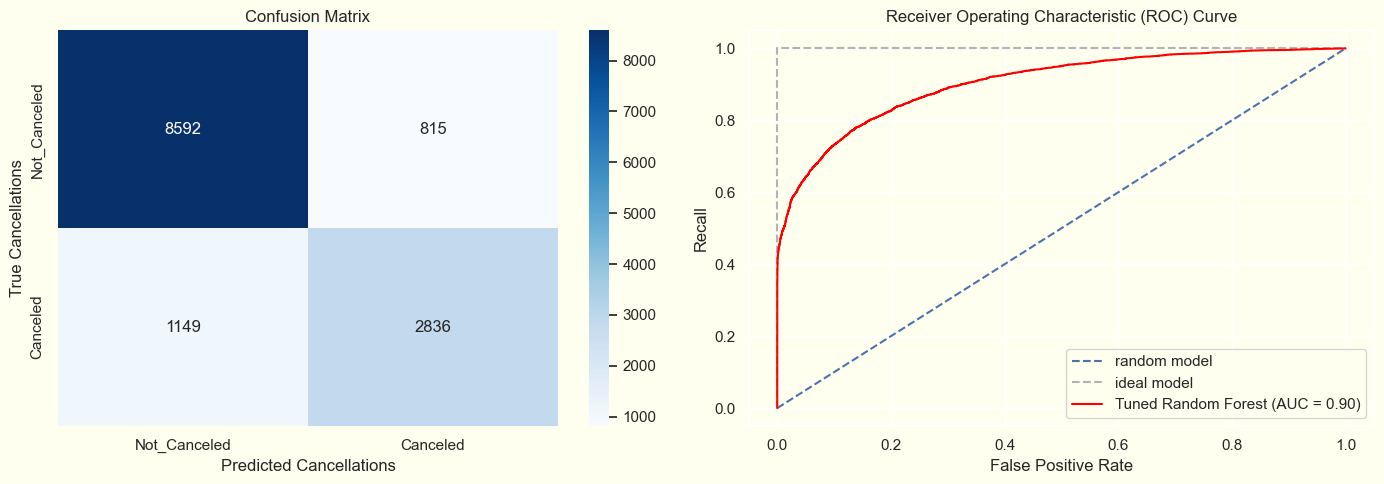

In [40]:
y_pred_final = model_Grid_refined.predict(X_testtr)
y_proba_final = model_Grid_refined.predict_proba(X_testtr)[:, 1]

print("Classification Report for Tuned Random Forest")
print("---------------------------------------------")
print(classification_report(y_test,
                            y_pred_final,
                            target_names=["Not_Canceled", "Canceled"]
                           )
)

auc_model = roc_auc_score(y_test, y_proba_final)
print("ROC-AUC Score:", auc_model)

fig, ax = plt.subplots(ncols=2,
                       figsize=(14, 5)
                      )

# Confusion Matrix
df_confmatrix = confusion_matrix(y_test, y_pred_final)

sns.heatmap(df_confmatrix,
            annot=True,
            fmt="d",
            cmap="Blues",
            xticklabels=["Not_Canceled", "Canceled"],
            yticklabels=["Not_Canceled", "Canceled"],
            ax=ax[0]
        )

ax[0].set(title="Confusion Matrix",
          xlabel="Predicted Cancellations",
          ylabel="True Cancellations"
        )

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test,
                                 y_proba_final,
                                 drop_intermediate=False
                                )

ax[1].plot([0, 1], [0, 1], linestyle="--", label="random model")
ax[1].plot([0, 0, 1], [0, 1, 1], color=".7", linestyle="--", label="ideal model")
ax[1].plot(fpr,
           tpr,
           color="red",
           label=f"Tuned Random Forest (AUC = {auc_model:.2f})"
          )

ax[1].set(title="Receiver Operating Characteristic (ROC) Curve",
          xlabel="False Positive Rate",
          ylabel="Recall"
         )

ax[1].legend()

plt.tight_layout()
plt.show()


The tuned Random Forest pipeline achieves strong overall performance on the untouched test set, with an accuracy of 0.85 and a weighted F1-score of 0.85.

For the cancellation class, the model reaches a precision of 0.78 and a recall of 0.71. This means that when the model predicts a cancellation, it is correct about 78% of the time, and it identifies about 71% of actual cancellations.

The ROC-AUC score of 0.90 indicates that the model has strong ability to distinguish between canceled and not-canceled bookings across different classification thresholds.


### Save Final Model

In [ ]:
joblib.dump(model_Grid_refined, MODELS_DIR / "random_forest_model.pkl", compress=3)

The preprocessing transformer was saved as `models/preprocessing_transformer.pkl`. The final tuned modeling pipeline, including SMOTE and Random Forest, is saved as `models/random_forest_model.pkl`.

Both files are needed for future predictions: new data must first be transformed with the saved preprocessing transformer, and then passed to the saved modeling pipeline.

<div style="background-color:  #dbf0c9; padding: 10px;">

## Feature Importance

</div>

To interpret the tuned Random Forest model, I examine the most important features used by the classifier.

Feature importance helps identify which booking characteristics contributed most to the model's predictions.


,Importance
lead_time,0.137017
deposit_type_Non Refund,0.110361
adr,0.078305
total_of_special_requests,0.075025
arrival_date_day_of_month,0.060062
arrival_date_week_number,0.057930
stays_in_week_nights,0.052939
arrival_date_month,0.040010
previous_cancellations,0.035502
booking_changes,0.031054


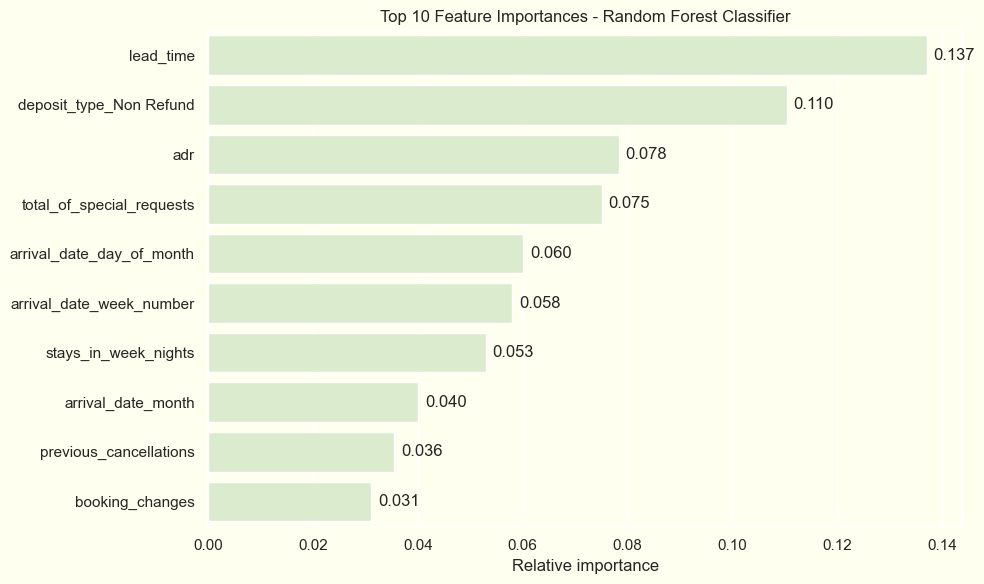

In [42]:
best_rf_model = model_Grid_refined.best_estimator_.named_steps["rf"]

feature_importances = pd.DataFrame(best_rf_model.feature_importances_,
                                   index = X_train_resampled.columns,
                                   columns = ["Importance"]
                                  )


feature_importances_sorted = feature_importances.sort_values(by = 'Importance',
                                                             ascending = False
                                                             )


top_10_features = feature_importances_sorted.head(10)

display(top_10_features)

plt.figure(figsize=(10, 6))

ax = sns.barplot(data=top_10_features,
                 x="Importance",
                 y=top_10_features.index,
                 color="#dbf0c9"
               )

plt.title("Top 10 Feature Importances - Random Forest Classifier")
plt.xlabel("Relative importance")
plt.ylabel("")

for container in ax.containers:
    ax.bar_label(container,
                 labels = [f"{value:.3f}" for value in top_10_features["Importance"]],
                 padding = 5
                )

plt.tight_layout()
plt.show()

The tuned Random Forest identifies `lead_time` as the most important predictor, followed by `deposit_type_Non Refund`, `adr`, and `total_of_special_requests`.

This suggests that cancellation risk is strongly influenced by booking timing, deposit policy, price level, and customer engagement signals. Longer lead times may increase the chance that plans change before arrival, while non-refundable deposit behavior shows a strong association with cancellation patterns in this dataset.

The presence of arrival-date variables such as `arrival_date_day_of_month`, `arrival_date_week_number`, and `arrival_date_month` suggests that cancellation behavior may also vary by timing, seasonality, or calendar effects.

`previous_cancellations` and `booking_changes` also appear among the top predictors, indicating that past behavior and modifications to the booking contain useful information about cancellation risk.

Overall, the feature-importance results are consistent with the EDA findings: cancellation behavior is shaped by a combination of timing, booking conditions, customer intent, past behavior, and stay characteristics.




## Optional Reduced-Feature Model

To test whether a simpler model can achieve similar performance, I train a Random Forest using only the top 10 most important features from the tuned model.

This is not the primary final model, but it helps assess whether the model can be simplified without losing too much predictive performance.


In [43]:
top_features = top_10_features.index.tolist()

X_train_top = X_traintr[top_features]
X_test_top = X_testtr[top_features]

rf_top_pipeline = ImbPipeline(steps=[("smote", SMOTE(random_state = 42)),
                                     ("rf", RandomForestClassifier(criterion = "entropy",
                                                                   max_depth = 30,
                                                                   max_features = "sqrt",
                                                                   max_leaf_nodes = None,
                                                                   min_samples_leaf = 1,
                                                                   min_samples_split = 2,
                                                                   n_estimators = 200,
                                                                   random_state = 42
                                                                  )
                                     )
                                    ]
                             )

rf_top_pipeline.fit(X_train_top, y_train)

y_pred_top = rf_top_pipeline.predict(X_test_top)
y_proba_top = rf_top_pipeline.predict_proba(X_test_top)[:, 1]


print("Classification Report for Reduced-Feature Random Forest")
print("-------------------------------------------------------")
print(classification_report(y_test,
                            y_pred_top,
                            target_names=["Not_Canceled", "Canceled"]
                           )
    )

print("ROC-AUC Score:", roc_auc_score(y_test, y_proba_top))


Classification Report for Reduced-Feature Random Forest
-------------------------------------------------------
              precision    recall  f1-score   support

Not_Canceled       0.86      0.89      0.88      9407
    Canceled       0.72      0.65      0.68      3985

    accuracy                           0.82     13392
   macro avg       0.79      0.77      0.78     13392
weighted avg       0.82      0.82      0.82     13392

ROC-AUC Score: 0.8654026160342165


The reduced-feature model performs reasonably well, but it underperforms the full tuned Random Forest pipeline.

Using only the top 10 features reduces ROC-AUC from 0.90 to 0.87 and lowers recall for canceled bookings from 0.71 to 0.65. This means the simpler model misses more actual cancellations.

For this project, the full tuned Random Forest pipeline is preferred because it provides stronger predictive performance, especially for identifying canceled bookings. The reduced-feature experiment is still useful because it shows that the top predictors contain substantial signal, but additional features improve the final model.



<div style="background-color:  #eff8e7; padding: 10px;">

## Business Conclusions

The final tuned Random Forest pipeline achieved strong performance on the untouched test set, with an accuracy of 0.85, a weighted F1-score of 0.85, and a ROC-AUC score of 0.90.

For the cancellation class, the model reached a precision of 0.78 and a recall of 0.71.

From a business perspective, this model could help hotels identify bookings with higher cancellation risk and support decisions related to room inventory, staffing, and revenue management.

The most important cancellation drivers were related to booking timing, deposit policy, price level, special requests, previous cancellation behavior, and calendar effects. These findings suggest that cancellation behavior is shaped by both customer commitment signals and booking context.

The reduced-feature experiment showed that using only the top 10 predictors still produced reasonable performance, but the full model performed better. Therefore, the full tuned Random Forest is preferred as the final model for this project.
</div>

### Possible Next Steps

- Test different classification thresholds depending on the business cost of false positives and false negatives.
- Compare model performance across hotel types or market segments.
- Package the preprocessing and model prediction steps into a reusable pipeline.
- Deploy a small Streamlit app to make cancellation-risk predictions from new booking data.

